In [1]:
import pandas as pd

df = pd.read_parquet('../data/Player-Games with Injuries.parquet')
df['Position'] = df['Position'].map({
    'PG': 1,
    'SG': 2,
    'SF': 3,
    'PF': 4,
    'C': 5,
})

In [2]:
print(df['playerteamName'].unique())

['Suns' 'Clippers' 'Celtics' 'Heat' 'Mavericks' 'Knicks' 'Spurs' 'Bulls'
 'Trail Blazers' 'Nets' 'Timberwolves' 'Hawks' 'Rockets' 'Lakers'
 'Thunder' 'Warriors' 'Pistons' 'Nuggets' '76ers' 'Cavaliers' 'Bobcats'
 'Bucks' 'Wizards' 'Grizzlies' 'Kings' 'Magic' 'Raptors' 'Pacers' 'Jazz'
 'Hornets' 'Pelicans']


In [3]:
from utils import test_model

ROC-AUC: 0.5832049755424926
PR-AUC: 0.24868648331648865


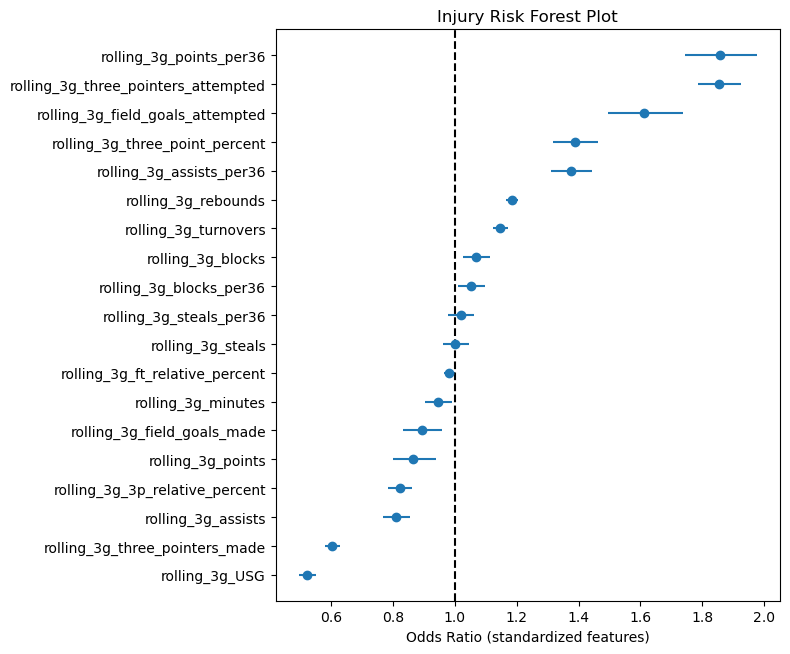

ROC-AUC: 0.5858174069382317
PR-AUC: 0.24895823558734143


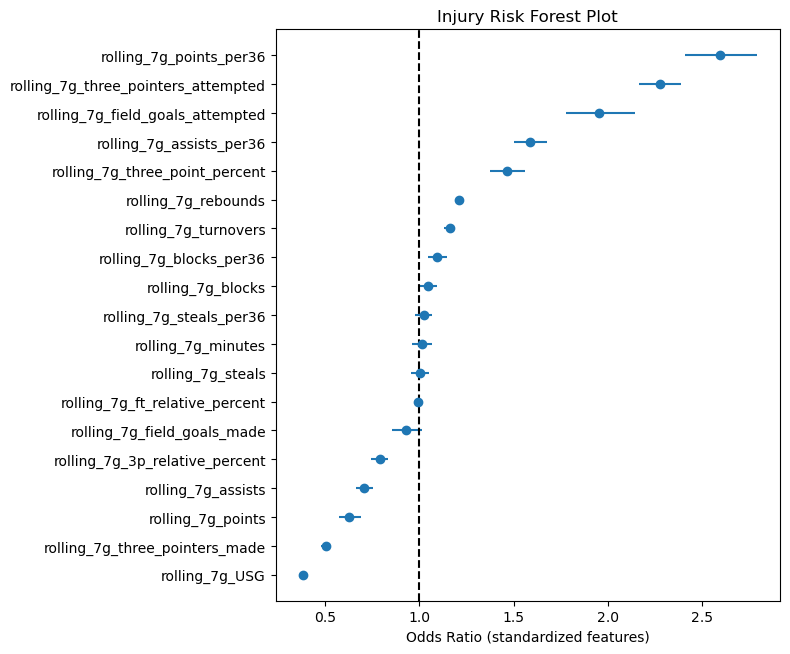

rolling 3 0.5832049755424926 0.24868648331648865
rolling 7 0.5858174069382317 0.24895823558734143


In [4]:
df_model_rolling3 = df[[c for c in df.columns if "rolling_3g" in c] + ['injury_within_14d', 'gameDateTimeEst_player']]
df_model_rolling3 = df_model_rolling3.dropna()

df_model_rolling7 = df[[c for c in df.columns if "rolling_7g" in c] + ['injury_within_14d', 'gameDateTimeEst_player']]
df_model_rolling7 = df_model_rolling7.dropna()

or_df_3, auc_3, ap_3 = test_model(df_model_rolling3)
or_df_7, auc_7, ap_7 = test_model(df_model_rolling7)

print('rolling 3', auc_3, ap_3)
print('rolling 7', auc_7, ap_7)

In [5]:
def clean_name(x):
    return x.replace("rolling_3g_", "").replace("rolling_7g_", "")

or_df_3_mod = or_df_3.copy()
or_df_7_mod = or_df_7.copy()

or_df_3_mod["feature"] = or_df_3_mod["feature"].apply(clean_name)
or_df_7_mod["feature"] = or_df_7_mod["feature"].apply(clean_name)

or_df_3_mod = or_df_3_mod.rename(columns={
    "OR": "OR_3",
    "lower": "lower_3",
    "upper": "upper_3"
})

or_df_7_mod = or_df_7_mod.rename(columns={
    "OR": "OR_7",
    "lower": "lower_7",
    "upper": "upper_7"
})

combined_or = or_df_3_mod.merge(or_df_7_mod, on="feature", how="inner")
combined_or["OR_ratio_3_vs_7"] = combined_or["OR_3"] / combined_or["OR_7"]

combined_or = combined_or.sort_values("OR_ratio_3_vs_7")
combined_or

,feature,OR_3,lower_3,upper_3,OR_7,lower_7,upper_7,OR_ratio_3_vs_7
18,points_per36,1.857547,1.744836,1.977539,2.593183,2.409864,2.790447,0.716319
17,three_pointers_attempted,1.854051,1.784981,1.925793,2.273682,2.165290,2.387500,0.815440
16,field_goals_attempted,1.612703,1.495255,1.739376,1.952293,1.777818,2.143891,0.826056
14,assists_per36,1.374736,1.309772,1.442922,1.587230,1.502120,1.677163,0.866123
6,minutes,0.945872,0.903798,0.989904,1.014609,0.962399,1.069652,0.932252
15,three_point_percent,1.387099,1.316086,1.461944,1.465595,1.376977,1.559917,0.946441
5,field_goals_made,0.893206,0.833248,0.957478,0.931566,0.855232,1.014712,0.958822
10,blocks_per36,1.051886,1.008541,1.097093,1.095314,1.046301,1.146622,0.960351
13,rebounds,1.185443,1.166040,1.205169,1.209502,1.187772,1.231629,0.980109
12,turnovers,1.147209,1.122931,1.172011,1.161150,1.132232,1.190808,0.987993


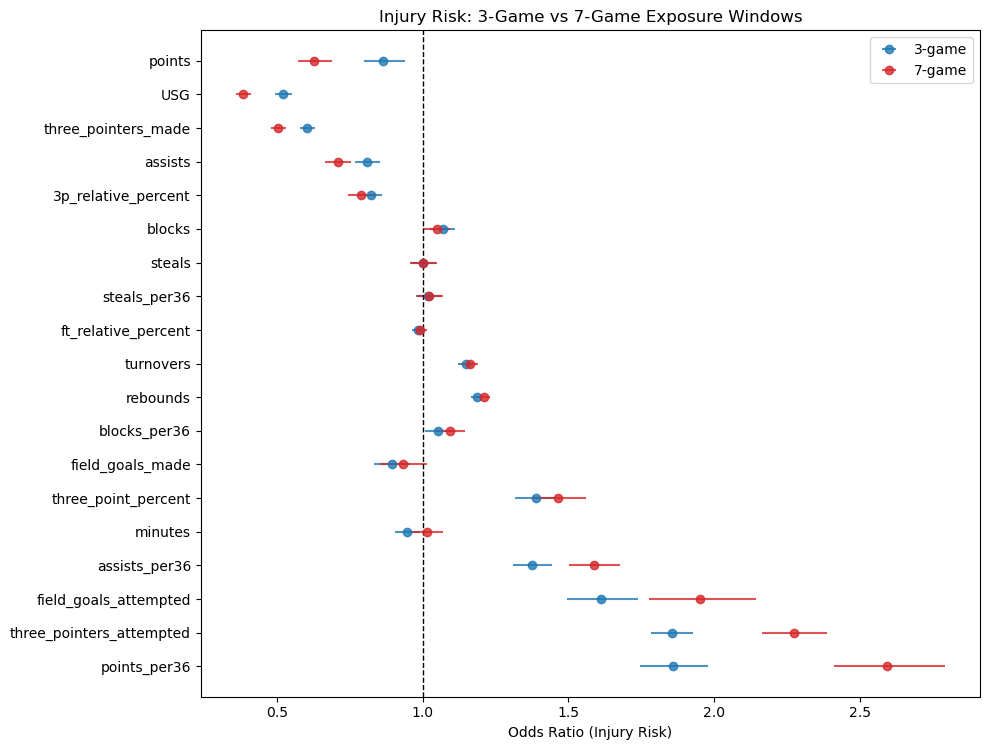

In [6]:
df3 = combined_or[["feature", "OR_3", "lower_3", "upper_3"]].copy()
df3.columns = ["feature", "OR", "lower", "upper"]
df3["model"] = "3-game"

df7 = combined_or[["feature", "OR_7", "lower_7", "upper_7"]].copy()
df7.columns = ["feature", "OR", "lower", "upper"]
df7["model"] = "7-game"

plot_df = pd.concat([df3, df7], ignore_index=True)

feature_order = (
    combined_or.sort_values("OR_7")["feature"].tolist()
)
plot_df["feature"] = pd.Categorical(plot_df["feature"], categories=feature_order, ordered=True)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, max(6, len(feature_order) * 0.4)))

colors = {"3-game": "tab:blue", "7-game": "tab:red"}

for model in ["3-game", "7-game"]:
    sub = plot_df[plot_df["model"] == model]

    ax.errorbar(
        sub["OR"],
        sub["feature"],
        xerr=[
            sub["OR"] - sub["lower"],
            sub["upper"] - sub["OR"]
        ],
        fmt="o",
        label=model,
        alpha=0.8,
        color=colors[model]
    )

ax.axvline(1, linestyle="--", color="black", linewidth=1)

ax.set_xlabel("Odds Ratio (Injury Risk)")
ax.set_title("Injury Risk: 3-Game vs 7-Game Exposure Windows")
ax.legend()

plt.tight_layout()
plt.show()

ROC-AUC: 0.5916882882689016
PR-AUC: 0.2554151959701635


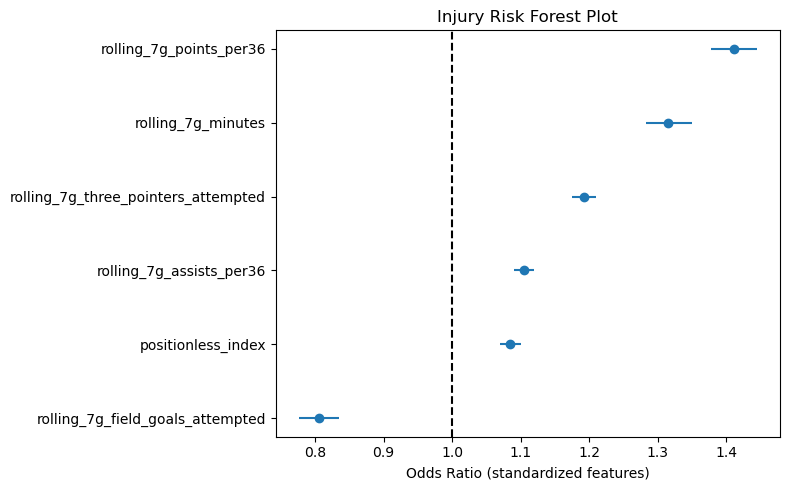

In [7]:
features = ['rolling_7g_points_per36', 'rolling_7g_field_goals_attempted',
            'rolling_7g_three_pointers_attempted', 'rolling_7g_assists_per36',
            'rolling_7g_minutes', 'positionless_index']
df_main_model = df[features + ['injury_within_14d', 'gameDateTimeEst_player']]
df_main_model = df_main_model.dropna()

odds, auc, ap = test_model(df_main_model)

In [8]:
print(odds, auc, ap)

                               feature        OR     lower     upper
2     rolling_7g_field_goals_attempted  0.805482  0.776243  0.835822
6                   positionless_index  1.084849  1.069984  1.099922
4             rolling_7g_assists_per36  1.104626  1.090270  1.119171
3  rolling_7g_three_pointers_attempted  1.192083  1.174645  1.209779
5                   rolling_7g_minutes  1.315493  1.282075  1.349782
1              rolling_7g_points_per36  1.410415  1.376880  1.444766 0.5916882882689016 0.2554151959701635
